# CSE3CI Lab 6B: TensorFlow for Classification

## Introduction

In previous lectures and labs, many of you have learned how to program with Python and built intelligent systems. In this lab, we will continue learning TensorFlow 2.x, focusing on classification tasks.

In this lab, you will learn:
- How to build simple neural network models for binary classification using TensorFlow 2.x
- How to use activation functions and loss functions for classification
- How to evaluate classification model performance

Note: TensorFlow is a tool for machine learning. While it contains a wide range of functionality, TensorFlow is mainly designed for deep neural network models. You are suggested to read the tutorials from the [website](https://www.tensorflow.org/tutorials/).

## Programming with TensorFlow 2.x

Based on what you have learned about regression in the previous lab, let's now tackle a binary classification task using TensorFlow 2.x. We'll create a neural network to classify data points into two categories.

TensorFlow version: 2.19.0
Data shapes - x: (200, 2), y: (200,)
Classes - 0: 100 samples, 1: 100 samples


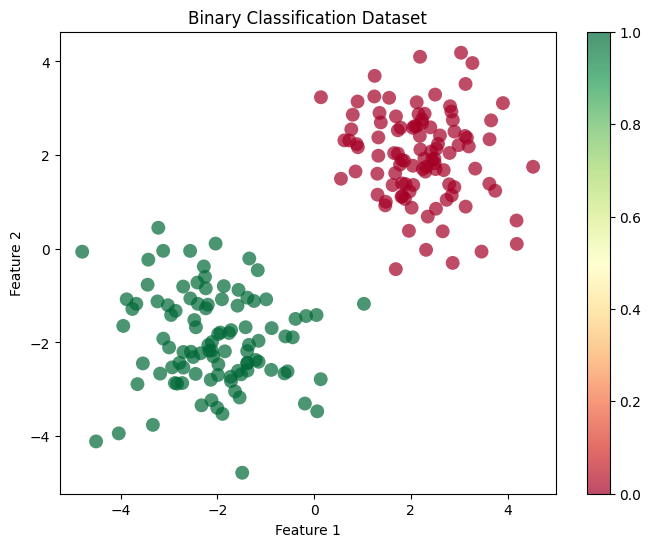

In [25]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

# Set seeds for reproducibility
tf.random.set_seed(1)
np.random.seed(1)

print(f"TensorFlow version: {tf.__version__}")

# Generate synthetic binary classification data
x0 = np.random.normal(2, 1, (100, 2))      # class 0: centered at (2, 2), shape=(100, 2)
y0 = np.zeros(100)                          # class 0 labels, shape=(100,)

x1 = np.random.normal(-2, 1, (100, 2))     # class 1: centered at (-2, -2), shape=(100, 2)
y1 = np.ones(100)                           # class 1 labels, shape=(100,)

# Combine the data
x = np.vstack((x0, x1)).astype(np.float32)  # Stack vertically, shape (200, 2)
y = np.hstack((y0, y1)).astype(np.int32)    # Stack horizontally, shape (200,)

print(f"Data shapes - x: {x.shape}, y: {y.shape}")
print(f"Classes - 0: {np.sum(y==0)} samples, 1: {np.sum(y==1)} samples")

# Visualize the data
plt.figure(figsize=(8, 6))
plt.scatter(x[:, 0], x[:, 1], c=y, s=100, lw=0, cmap='RdYlGn', alpha=0.7)
plt.colorbar()
plt.title('Binary Classification Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

Building neural network with manual operations...
Model parameters:
W1 shape: (2, 10) (Input to Hidden)
b1 shape: (10,) (Hidden bias)
W2 shape: (10, 2) (Hidden to Output)
b2 shape: (2,) (Output bias)

Optimizer: SGD
Learning rate: 0.05000000074505806

TRAINING NEURAL NETWORK


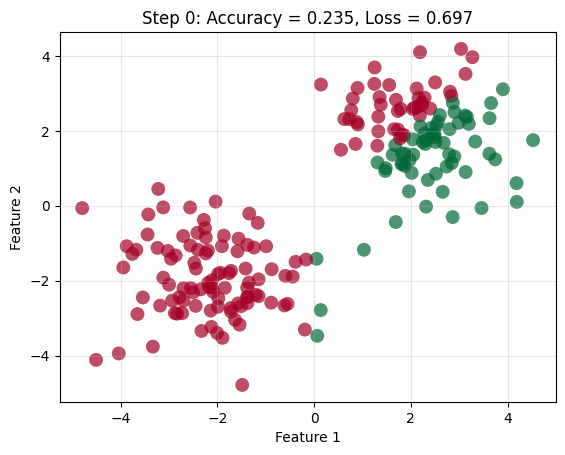

Step   0: Loss = 0.6975, Accuracy = 0.2350


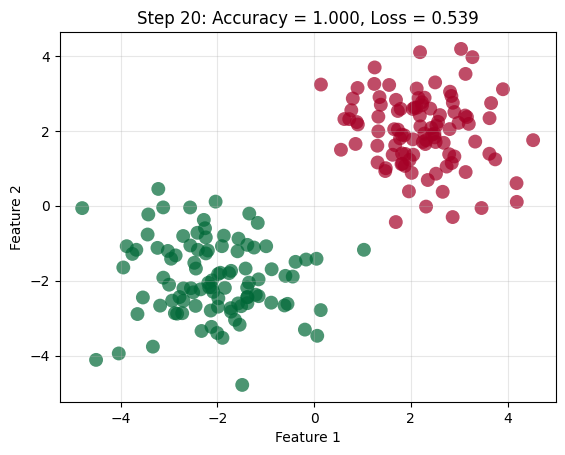

Step  20: Loss = 0.5393, Accuracy = 1.0000


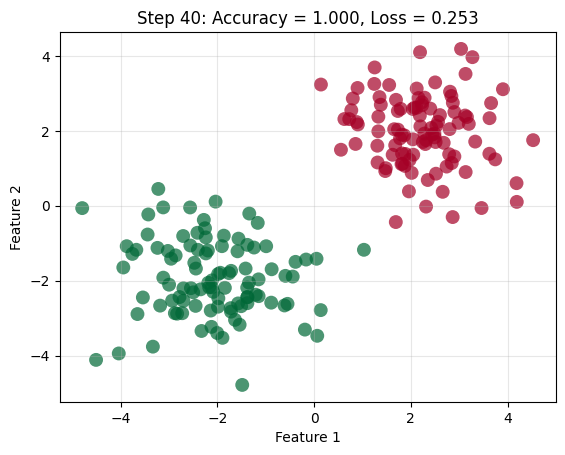

Step  40: Loss = 0.2525, Accuracy = 1.0000


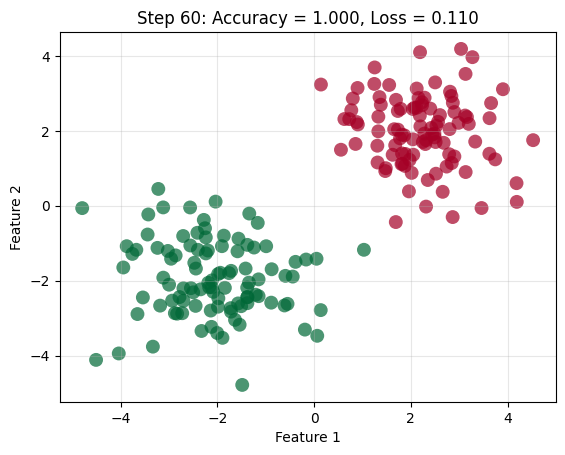

Step  60: Loss = 0.1101, Accuracy = 1.0000


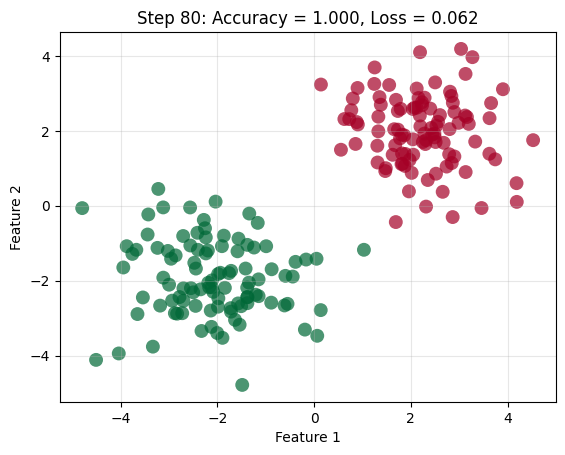

Step  80: Loss = 0.0625, Accuracy = 1.0000
TRAINING COMPLETED
Final Loss: 0.0429
Final Accuracy: 1.0000

Final Model Parameters:
W1 (first 3 values): [-0.06747966  0.02289132  0.3467099 ]
b1 (all values): [-0.01978859  0.01629333  0.13847324  0.06461631  0.20894803  0.11815758
  0.19674143  0.04038086  0.20511664  0.00567244]
W2 (first 3 values): [-0.05346636 -0.01502695 -0.0367098 ]
b2 (all values): [ 0.01638822 -0.0163882 ]


In [23]:
# Build the neural network using low-level TensorFlow 2.x operations
print("Building neural network with manual operations...")

# Define model parameters (weights and biases)
# Input layer: 2 features -> Hidden layer: 10 nodes -> Output layer: 2 classes
W1 = tf.Variable(tf.random.normal([2, 10], stddev=0.1, dtype=tf.float32), name='W1')
b1 = tf.Variable(tf.zeros([10], dtype=tf.float32), name='b1')
W2 = tf.Variable(tf.random.normal([10, 2], stddev=0.1, dtype=tf.float32), name='W2')
b2 = tf.Variable(tf.zeros([2], dtype=tf.float32), name='b2')

print(f"Model parameters:")
print(f"W1 shape: {W1.shape} (Input to Hidden)")
print(f"b1 shape: {b1.shape} (Hidden bias)")
print(f"W2 shape: {W2.shape} (Hidden to Output)")
print(f"b2 shape: {b2.shape} (Output bias)")

def forward_pass(x_input):
    """
    Manual neural network forward pass
    Args:
        x_input: Input features, shape (batch_size, 2)
    Returns:
        logits: Raw output values, shape (batch_size, 2)
    """
    # Hidden layer: apply linear transformation + ReLU activation
    z1 = tf.matmul(x_input, W1) + b1  # Linear transformation
    a1 = tf.nn.relu(z1)               # ReLU activation

    # Output layer: apply linear transformation (no activation yet)
    z2 = tf.matmul(a1, W2) + b2       # Output logits

    return z2

def compute_loss(y_true, logits):
    """
    Compute sparse categorical crossentropy loss
    Args:
        y_true: True labels, shape (batch_size,)
        logits: Raw model outputs, shape (batch_size, 2)
    Returns:
        loss: Scalar loss value
    """
    loss = tf.reduce_mean(tf.nn.sparse_softmax_cross_entropy_with_logits(
        labels=y_true, logits=logits))
    return loss

def compute_accuracy(y_true, logits):
    """
    Compute classification accuracy
    Args:
        y_true: True labels, shape (batch_size,)
        logits: Raw model outputs, shape (batch_size, 2)
    Returns:
        accuracy: Scalar accuracy value
    """
    predictions = tf.argmax(logits, axis=1)
    accuracy = tf.reduce_mean(tf.cast(tf.equal(predictions, tf.cast(y_true, tf.int64)), tf.float32))
    return accuracy

def softmax_predictions(logits):
    """
    Convert logits to probabilities using softmax
    Args:
        logits: Raw model outputs, shape (batch_size, 2)
    Returns:
        probabilities: Softmax probabilities, shape (batch_size, 2)
    """
    return tf.nn.softmax(logits)

# Set up optimizer
optimizer = tf.optimizers.SGD(learning_rate=0.05)
print(f"\nOptimizer: {optimizer.__class__.__name__}")
print(f"Learning rate: {optimizer.learning_rate.numpy()}")

# Training loop with detailed visualization
print("\n" + "="*50)
print("TRAINING NEURAL NETWORK")
print("="*50)

plt.ion()  # Enable interactive plotting
training_losses = []
training_accuracies = []

for step in range(100):  # Increased to 100 iterations for better convergence
    # Forward pass and loss computation within GradientTape
    with tf.GradientTape() as tape:
        logits = forward_pass(x)
        loss = compute_loss(y, logits)

    # Compute gradients with respect to all trainable variables
    gradients = tape.gradient(loss, [W1, b1, W2, b2])

    # Apply gradients to update parameters
    optimizer.apply_gradients(zip(gradients, [W1, b1, W2, b2]))

    # Calculate metrics
    accuracy = compute_accuracy(y, logits)
    probabilities = softmax_predictions(logits)
    predicted_classes = tf.argmax(probabilities, axis=1)
    # Store training history
    training_losses.append(loss.numpy())
    training_accuracies.append(accuracy.numpy())

    # Visualize training progress every 20 steps
    if step % 20 == 0:
        plt.cla()
        plt.scatter(x[:, 0], x[:, 1], c=predicted_classes, s=100, lw=0, cmap='RdYlGn', alpha=0.7)
        plt.title(f'Step {step}: Accuracy = {accuracy.numpy():.3f}, Loss = {loss.numpy():.3f}')
        plt.xlabel('Feature 1')
        plt.ylabel('Feature 2')
        plt.grid(True, alpha=0.3)
        plt.pause(0.1)

        print(f"Step {step:3d}: Loss = {loss.numpy():.4f}, Accuracy = {accuracy.numpy():.4f}")

plt.ioff()  # Disable interactive plotting
print("="*50)
print("TRAINING COMPLETED")
print("="*50)
print(f"Final Loss: {training_losses[-1]:.4f}")
print(f"Final Accuracy: {training_accuracies[-1]:.4f}")

# Display final model parameters
print(f"\nFinal Model Parameters:")
print(f"W1 (first 3 values): {W1.numpy().flatten()[:3]}")
print(f"b1 (all values): {b1.numpy()}")
print(f"W2 (first 3 values): {W2.numpy().flatten()[:3]}")
print(f"b2 (all values): {b2.numpy()}")

## Exercises and Exploration

Now that you understand how to build neural networks from scratch using low-level TensorFlow 2.x operations, try the following modifications:

### Basic Modifications
1. **Change training iterations**: Modify `range(100)` to `range(200)` or `range(500)` and observe how accuracy improves over time.

2. **Experiment with network architecture**:
   - Change the number of hidden nodes from 10 to 5, 20, or 50
   - Observe how the model capacity affects learning

3. **Try different optimizers**:
   ```python
   optimizer = tf.optimizers.Adam(learning_rate=0.01)
   # or
   optimizer = tf.optimizers.RMSprop(learning_rate=0.01)
   ```

4. **Adjust learning rate**: Try values like 0.01, 0.1, or 0.5 and see how it affects convergence speed and stability.

### Advanced Modifications
5. **Add another hidden layer**: Modify the network to have two hidden layers (e.g., 2 -> 10 -> 5 -> 2)

6. **Try different activation functions**: Replace ReLU with:
   ```python
   a1 = tf.nn.tanh(z1)  # or tf.nn.sigmoid(z1)
   ```

7. **Add regularization**: Implement L2 regularization by adding penalty terms to the loss:
   ```python
   l2_loss = tf.nn.l2_loss(W1) + tf.nn.l2_loss(W2)
   total_loss = loss + 0.01 * l2_loss
   ```

### Analysis Tasks
8. **Plot training curves**: Create plots showing how loss and accuracy change during training

9. **Experiment with initialization**: Try different weight initialization strategies

10. **Decision boundary visualization**: Create a function to visualize the decision boundary learned by the model

Complete the exercises in the cell below:

EXERCISE: DEEPER NEURAL NETWORK WITH MANUAL IMPLEMENTATION
Building deeper network: 2 -> 15 -> 8 -> 2
Using Adam optimizer with learning rate: 0.009999999776482582

Training deeper network...
Step   0: Loss = 0.6800, Accuracy = 0.8000
Step  30: Loss = 0.0097, Accuracy = 1.0000
Step  60: Loss = 0.0067, Accuracy = 1.0000
Step  90: Loss = 0.0064, Accuracy = 1.0000
Step 120: Loss = 0.0061, Accuracy = 1.0000

Deep Network Final Results:
Loss: 0.0060, Accuracy: 1.0000


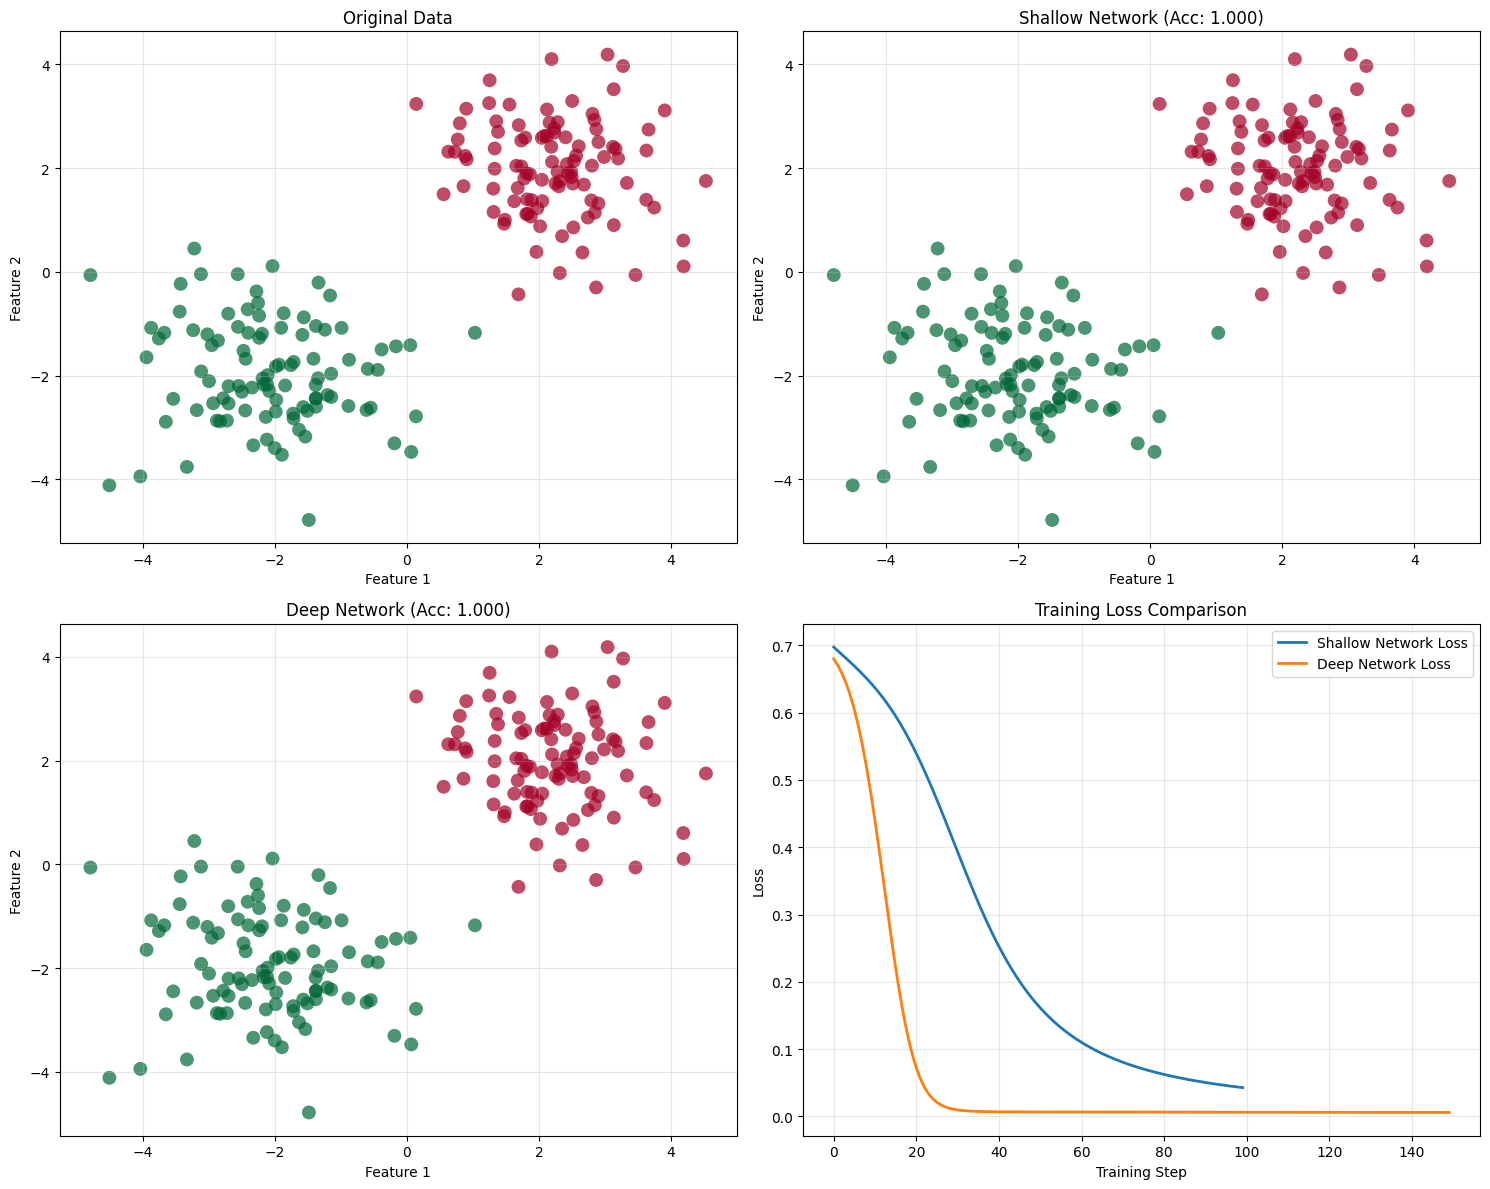


DETAILED ANALYSIS

Shallow Network (2->10->2) Analysis:
  Accuracy: 1.0000
  Class 0 predictions: 100
  Class 1 predictions: 100
  Average confidence: 0.9601

Deep Network (2->15->8->2) Analysis:
  Accuracy: 1.0000
  Class 0 predictions: 100
  Class 1 predictions: 100
  Average confidence: 0.9994

Generating decision boundary visualizations...


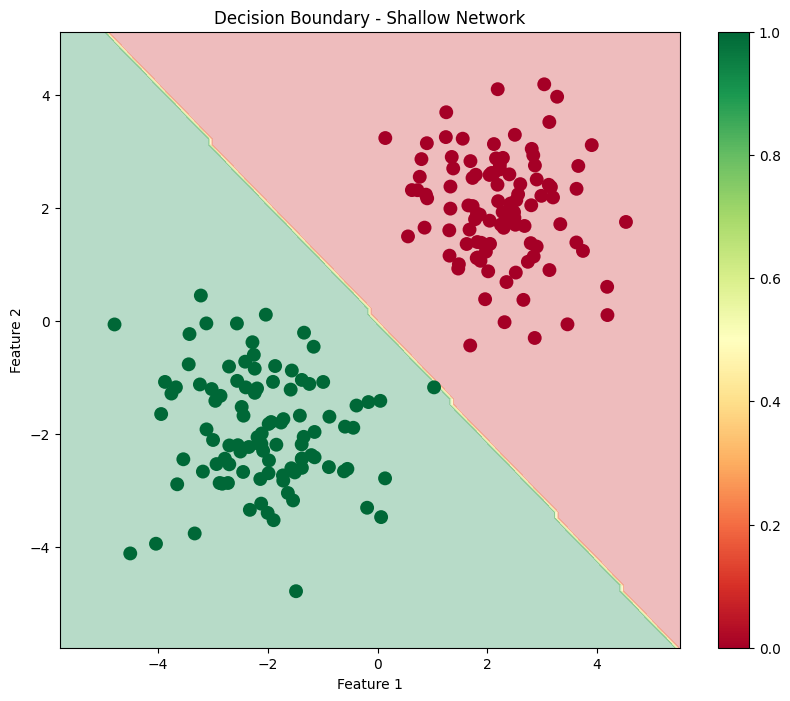

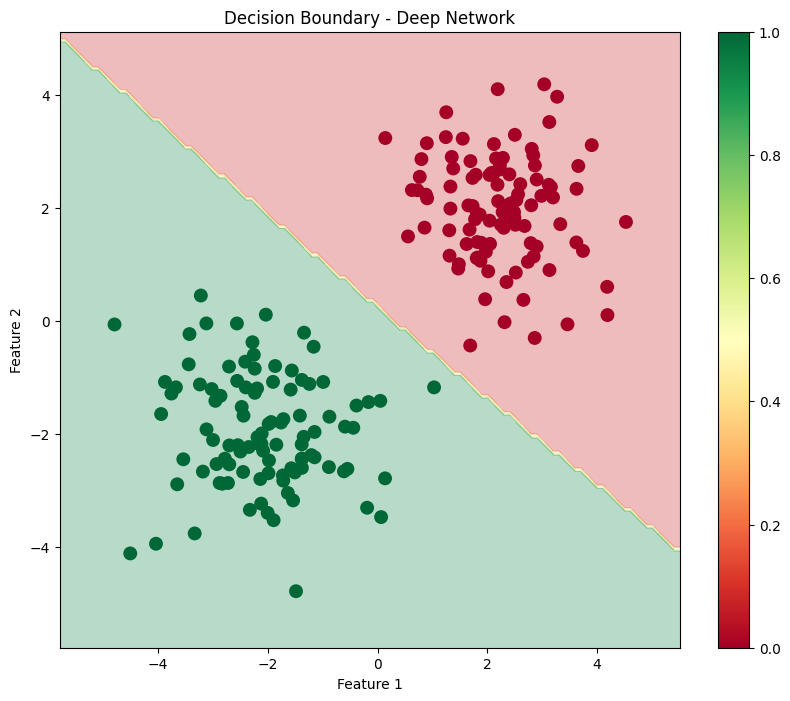

In [24]:
# Exercise: Build a deeper network manually and compare different configurations

print("="*60)
print("EXERCISE: DEEPER NEURAL NETWORK WITH MANUAL IMPLEMENTATION")
print("="*60)

# 1. Build a deeper network: 2 -> 15 -> 8 -> 2
print("Building deeper network: 2 -> 15 -> 8 -> 2")

# Define parameters for deeper network
W1_deep = tf.Variable(tf.random.normal([2, 15], stddev=0.1, dtype=tf.float32), name='W1_deep')
b1_deep = tf.Variable(tf.zeros([15], dtype=tf.float32), name='b1_deep')
W2_deep = tf.Variable(tf.random.normal([15, 8], stddev=0.1, dtype=tf.float32), name='W2_deep')
b2_deep = tf.Variable(tf.zeros([8], dtype=tf.float32), name='b2_deep')
W3_deep = tf.Variable(tf.random.normal([8, 2], stddev=0.1, dtype=tf.float32), name='W3_deep')
b3_deep = tf.Variable(tf.zeros([2], dtype=tf.float32), name='b3_deep')

def deeper_forward_pass(x_input):
    """
    Deeper neural network forward pass: 2 -> 15 -> 8 -> 2
    """
    # First hidden layer
    z1 = tf.matmul(x_input, W1_deep) + b1_deep
    a1 = tf.nn.relu(z1)

    # Second hidden layer
    z2 = tf.matmul(a1, W2_deep) + b2_deep
    a2 = tf.nn.relu(z2)

    # Output layer
    z3 = tf.matmul(a2, W3_deep) + b3_deep

    return z3

# 2. Try Adam optimizer instead of SGD
optimizer_adam = tf.optimizers.Adam(learning_rate=0.01)
print(f"Using Adam optimizer with learning rate: {optimizer_adam.learning_rate.numpy()}")

# 3. Training the deeper network
print("\nTraining deeper network...")
deep_losses = []
deep_accuracies = []

for step in range(150):  # More epochs for deeper network
    with tf.GradientTape() as tape:
        logits_deep = deeper_forward_pass(x)
        loss_deep = compute_loss(y, logits_deep)

        # Add L2 regularization
        l2_reg = 0.001 * (tf.nn.l2_loss(W1_deep) + tf.nn.l2_loss(W2_deep) + tf.nn.l2_loss(W3_deep))
        total_loss = loss_deep + l2_reg

    # Compute gradients for all parameters
    gradients = tape.gradient(total_loss, [W1_deep, b1_deep, W2_deep, b2_deep, W3_deep, b3_deep])
    optimizer_adam.apply_gradients(zip(gradients, [W1_deep, b1_deep, W2_deep, b2_deep, W3_deep, b3_deep]))

    # Calculate metrics
    accuracy_deep = compute_accuracy(y, logits_deep)
    deep_losses.append(total_loss.numpy())
    deep_accuracies.append(accuracy_deep.numpy())

    if step % 30 == 0:
        print(f"Step {step:3d}: Loss = {total_loss.numpy():.4f}, Accuracy = {accuracy_deep.numpy():.4f}")

print(f"\nDeep Network Final Results:")
print(f"Loss: {deep_losses[-1]:.4f}, Accuracy: {deep_accuracies[-1]:.4f}")

# 4. Compare results visually
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# Original data
ax1.scatter(x[:, 0], x[:, 1], c=y, s=100, lw=0, cmap='RdYlGn', alpha=0.7)
ax1.set_title('Original Data')
ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Feature 2')
ax1.grid(True, alpha=0.3)

# Shallow network predictions
logits_shallow = forward_pass(x)
pred_shallow = tf.argmax(logits_shallow, axis=1)
ax2.scatter(x[:, 0], x[:, 1], c=pred_shallow, s=100, lw=0, cmap='RdYlGn', alpha=0.7)
ax2.set_title(f'Shallow Network (Acc: {training_accuracies[-1]:.3f})')
ax2.set_xlabel('Feature 1')
ax2.set_ylabel('Feature 2')
ax2.grid(True, alpha=0.3)

# Deep network predictions
logits_final = deeper_forward_pass(x)
pred_deep = tf.argmax(logits_final, axis=1)
ax3.scatter(x[:, 0], x[:, 1], c=pred_deep, s=100, lw=0, cmap='RdYlGn', alpha=0.7)
ax3.set_title(f'Deep Network (Acc: {deep_accuracies[-1]:.3f})')
ax3.set_xlabel('Feature 1')
ax3.set_ylabel('Feature 2')
ax3.grid(True, alpha=0.3)

# Training curves comparison
ax4.plot(training_losses, label='Shallow Network Loss', linewidth=2)
ax4.plot(deep_losses, label='Deep Network Loss', linewidth=2)
ax4.set_title('Training Loss Comparison')
ax4.set_xlabel('Training Step')
ax4.set_ylabel('Loss')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 5. Detailed analysis
print("\n" + "="*60)
print("DETAILED ANALYSIS")
print("="*60)

def analyze_model_predictions(logits, model_name):
    """Analyze model predictions in detail"""
    probabilities = tf.nn.softmax(logits)
    predictions = tf.argmax(probabilities, axis=1)
    accuracy = compute_accuracy(y, logits)

    print(f"\n{model_name} Analysis:")
    print(f"  Accuracy: {accuracy.numpy():.4f}")
    print(f"  Class 0 predictions: {tf.reduce_sum(tf.cast(predictions == 0, tf.int32)).numpy()}")
    print(f"  Class 1 predictions: {tf.reduce_sum(tf.cast(predictions == 1, tf.int32)).numpy()}")

    # Calculate confidence (max probability)
    max_probs = tf.reduce_max(probabilities, axis=1)
    avg_confidence = tf.reduce_mean(max_probs)
    print(f"  Average confidence: {avg_confidence.numpy():.4f}")

analyze_model_predictions(forward_pass(x), "Shallow Network (2->10->2)")
analyze_model_predictions(deeper_forward_pass(x), "Deep Network (2->15->8->2)")

# 6. Decision boundary visualization function
def plot_decision_boundary(forward_func, title):
    """Plot the decision boundary of a neural network"""
    h = 0.1  # Step size
    x_min, x_max = x[:, 0].min() - 1, x[:, 0].max() + 1
    y_min, y_max = x[:, 1].min() - 1, x[:, 1].max() + 1

    # Create a mesh grid
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # Make predictions on the mesh grid
    mesh_points = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)
    mesh_logits = forward_func(mesh_points)
    mesh_predictions = tf.argmax(mesh_logits, axis=1).numpy()

    # Reshape the predictions to match the mesh grid
    mesh_predictions = mesh_predictions.reshape(xx.shape)

    # Plot the decision boundary
    plt.figure(figsize=(10, 8))
    plt.contourf(xx, yy, mesh_predictions, alpha=0.3, cmap='RdYlGn')
    plt.scatter(x[:, 0], x[:, 1], c=y, s=100, lw=0, cmap='RdYlGn', edgecolors='black')
    plt.title(f'Decision Boundary - {title}')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.colorbar()
    plt.show()

print("\nGenerating decision boundary visualizations...")
plot_decision_boundary(forward_pass, "Shallow Network")
plot_decision_boundary(deeper_forward_pass, "Deep Network")

## Summary

In this lab, you have learned to build neural networks from scratch using low-level TensorFlow 2.x operations:

### Key Classification Concepts
1. **Binary Classification**: Distinguishing between two classes using neural networks
2. **Forward Pass**: Manual implementation of neural network computations
3. **Logits vs Probabilities**: Understanding raw outputs vs softmax-normalized probabilities
4. **Cross-entropy Loss**: The standard loss function for classification tasks
5. **Gradient Computation**: Using `tf.GradientTape()` for automatic differentiation

### Manual Neural Network Implementation
1. **Parameter Definition**: Creating trainable variables for weights and biases
   ```python
   W1 = tf.Variable(tf.random.normal([input_size, hidden_size]))
   b1 = tf.Variable(tf.zeros([hidden_size]))
   ```

2. **Forward Pass Function**: Manual matrix multiplications and activations
   ```python
   z1 = tf.matmul(x, W1) + b1    # Linear transformation
   a1 = tf.nn.relu(z1)           # Activation function
   ```

3. **Loss Computation**: Implementing cross-entropy loss manually
4. **Training Loop**: Using GradientTape for gradient computation and parameter updates

### Educational Benefits of Manual Implementation
- **Deep Understanding**: You now understand exactly what happens inside a neural network
- **Debugging Skills**: Easier to debug when you control every operation
- **Flexibility**: Can implement custom architectures and loss functions
- **Foundation Knowledge**: Prepares you for advanced topics like custom layers and models

### Network Architecture Insights
- **Shallow Network** (2→10→2): Simple but effective for linearly separable data
- **Deep Network** (2→15→8→2): More parameters and capacity for complex patterns
- **Activation Functions**: ReLU introduces non-linearity enabling complex decision boundaries
- **Regularization**: L2 penalty helps prevent overfitting

### TensorFlow 2.x Advantages for Manual Implementation
1. **Eager Execution**: Immediate operation execution makes debugging easier
2. **Automatic Differentiation**: `tf.GradientTape()` handles gradient computation
3. **No Sessions**: Direct variable access and manipulation
4. **Pythonic Code**: Natural Python syntax throughout

### Key Takeaways
1. Neural networks are fundamentally matrix operations with non-linear activations
2. Training involves iterative gradient-based parameter updates
3. Deeper networks can learn more complex patterns but require careful training
4. Understanding the mathematics helps in designing better architectures

This hands-on approach gives you the foundation to understand and implement any neural network architecture, making you ready for advanced deep learning topics!